In [1]:
import re

import gensim
import gensim.corpora as corpora
import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy

from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [3]:
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_color = "#00bfbf"

In [4]:
data = pd.read_csv("Files/fake_news_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


fake_or_factual
Factual News    100
Fake News        98
Name: count, dtype: int64


Text(0.5, 1.0, 'Count of article classification')

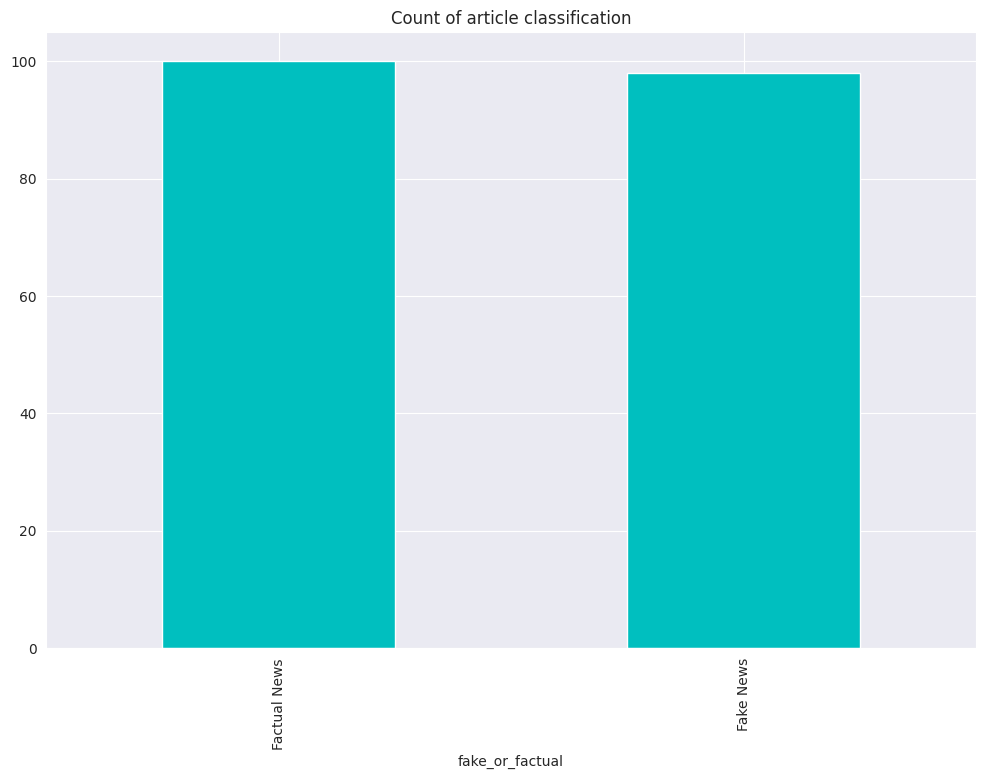

In [6]:
print(data.fake_or_factual.value_counts())
data.fake_or_factual.value_counts().plot(kind="bar", color=default_plot_color)
plt.title("Count of article classification")

### POS TAGGING

In [7]:
spacy.util.get_installed_models()

['en_core_web_sm']

In [8]:
nlp = spacy.load("en_core_web_sm")

In [24]:
fake_news = data[data.fake_or_factual == "Fake News"]
fake_spacy_docs = list(nlp.pipe(fake_news.text))
factual_news = data[data.fake_or_factual == "Factual News"]
fact_spacy_docs = list(nlp.pipe(factual_news.text))

In [28]:
factual_news.iloc[3].text
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [43]:
def loop_tags(spacy_docs):
    tags_df = []
    columns = ["token", "ner_tag", "pos_tag"]
    for idx, doc in enumerate(spacy_docs):
        tags = extract_token_tags(doc)
        tags = pd.DataFrame(tags)
        tags.columns = columns
        tags_df.append(tags)
    return pd.concat(tags_df)

In [47]:
fake_tags_df = loop_tags(fake_spacy_docs)
fact_tags_df = loop_tags(fact_spacy_docs)
fake_tags_df

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
743,.,,PUNCT
744,Via,,PROPN
745,:,,PUNCT
746,Campus,PERSON,PROPN


In [76]:
print(fake_news.iloc[0].text[:70])
def pos_counts(tags_df):
    return tags_df.groupby(["token", "pos_tag"]).size().reset_index(name="counts").sort_values(by="counts", ascending=False)
pos_counts_fake = pos_counts(fake_tags_df)
pos_counts_fact = pos_counts(fact_tags_df)
pos_counts_fact

There are two small problems with your analogy Susan  Jesus was NOT a 


,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
...,...,...,...
2909,crossing,VERB,1
2911,crucial,ADJ,1
2913,cruise,NOUN,1
2914,crusade,NOUN,1


In [89]:
# Let's check the frequency of POS (nouns or adverbs)
pos_counts_fake.groupby("pos_tag")["token"].count().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [91]:
# Let's get the first 15 nouns from the fake pos tag df
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


### Named Entities

In [101]:
def top_entities(tags_df):
    top_entity = tags_df[tags_df["ner_tag"] != ""]  # Get entities that are not blank
    top_entity = top_entity.groupby(["token", "ner_tag"]).size().reset_index(name="counts")
    top_entity = top_entity.sort_values(by="counts", ascending=False)
    return top_entity

top_entities_fake = top_entities(fake_tags_df)
top_entities_fact = top_entities(fact_tags_df)
top_entities_fact

,token,ner_tag,counts
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
...,...,...,...
804,German,NORP,1
803,Georgia,GPE,1
801,George,ORG,1
800,Geological,ORG,1


Text(0.5, 1.0, 'Most Common Name Entities in Fake News')

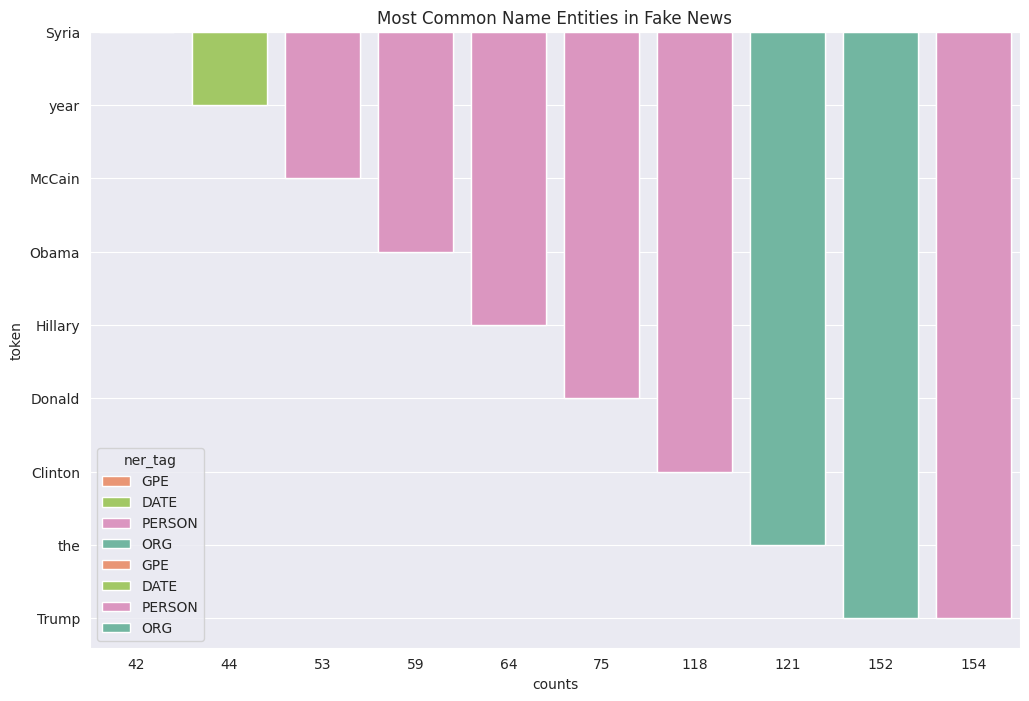

In [106]:
# Use color to highlight common entities
ner_palette = {
    "ORG": sns.color_palette("Set2").as_hex()[0],
    "GPE": sns.color_palette("Set2").as_hex()[1],
    "NORP": sns.color_palette("Set2").as_hex()[2],
    "PERSON": sns.color_palette("Set2").as_hex()[3],
    "DATE": sns.color_palette("Set2").as_hex()[4],
    "CARDINAL": sns.color_palette("Set2").as_hex()[5],
    "PERCENT": sns.color_palette("Set2").as_hex()[6],
}
sns.barplot(
    x="counts", y="token", hue="ner_tag", palette=ner_palette, data=top_entities_fake[:10], orient="v", dodge=False
).set_title("Most Common Name Entities in Fake News")

Text(0.5, 1.0, 'Most Common Name Entities in Factual News')

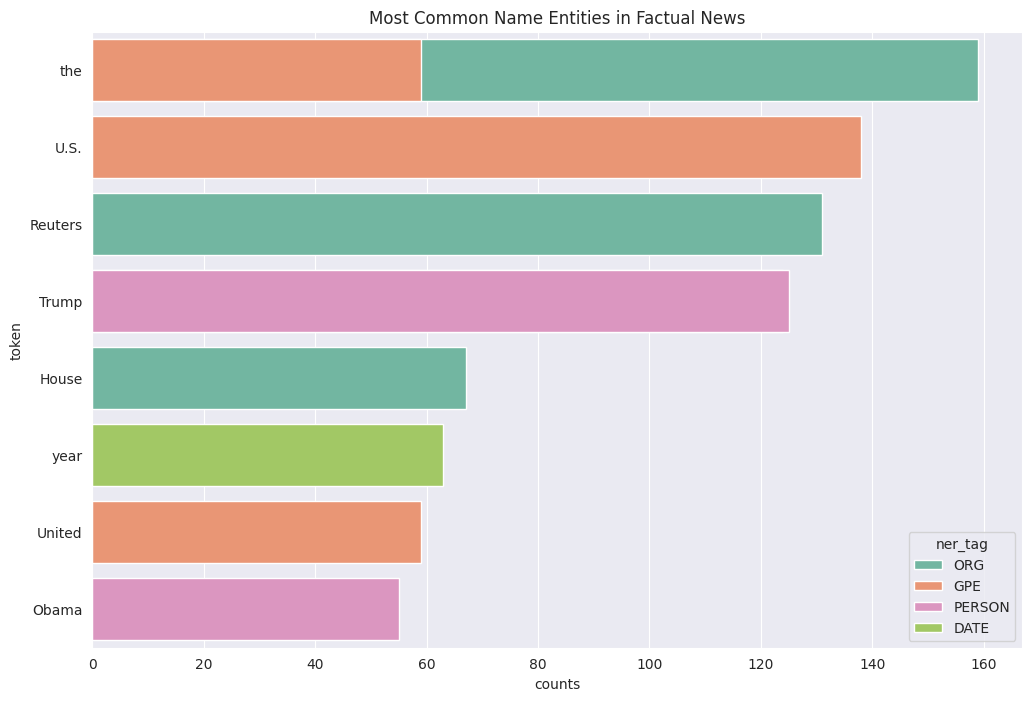

In [111]:
# As you can see, people are more in the fake news chart. In factual news, mostly organizations.
sns.barplot(
    x="counts", y="token", hue="ner_tag", palette=ner_palette, data=top_entities_fact[:10], orient="h", dodge=False
).set_title("Most Common Name Entities in Factual News")

### Text Pre-processing and Clean-Up

In [144]:
# Remove the hyphenated text i.e., 'BEIJING (Reuters) - U.S.' = 'U.S.'
data["text_clean"] = data.apply(lambda x: re.sub(r"^[^-]*-\s", "", x["text"]), axis=1)
def clean_text(text):
    text = text.lower() # Lowercase the text
    # text = re.sub(r'[^a-z\s]', '', text) # Remove special characters and numbers
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuations
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text
data.text_clean = data.text_clean.apply(clean_text)
data

,title,text,date,fake_or_factual,text_clean,text_lem
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,there are two small problems with your analogy...,"[t, w, o, , s, m, a, l, l, , p, r, o, b, l, ..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried in trump s bonkers interview with new y...,"[b, u, r, i, e, d, , t, r, u, m, p, , b, o, ..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make up over 50 percent of this country ...,"[w, o, m, e, n, , m, a, k, e, , 5, 0, , p, ..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said on monday...,"[u, s, , d, e, f, e, n, s, e, , s, e, c, r, ..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland s political parties are rapid...,"[n, o, r, t, h, e, r, n, , i, r, e, l, a, n, ..."
...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,well that didn t take long look for the first ...,"[w, e, l, l, , t, a, k, e, , l, o, n, g, , ..."
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,florida s toxic and dangerous stand your groun...,"[f, l, o, r, i, d, a, , t, o, x, i, c, , d, ..."
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,as politico reports an almost neckandneck race...,"[p, o, l, i, t, i, c, o, , r, e, p, o, r, t, ..."
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,former fbi director james comey had requested ...,"[f, o, r, m, e, r, , f, b, i, , d, i, r, e, ..."


In [145]:
en_stopwords = stopwords.words("english")
data.text_clean = data.text_clean.apply(lambda x: " ".join([word for word in x.split() if word not in en_stopwords]))
data

,title,text,date,fake_or_factual,text_clean,text_lem
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,two small problems analogy susan jesus muslim ...,"[t, w, o, , s, m, a, l, l, , p, r, o, b, l, ..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,buried trump bonkers interview new york times ...,"[b, u, r, i, e, d, , t, r, u, m, p, , b, o, ..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,women make 50 percent country grossly underrep...,"[w, o, m, e, n, , m, a, k, e, , 5, 0, , p, ..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,us defense secretary jim mattis said monday ru...,"[u, s, , d, e, f, e, n, s, e, , s, e, c, r, ..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,northern ireland political parties rapidly run...,"[n, o, r, t, h, e, r, n, , i, r, e, l, a, n, ..."
...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,well take long look first beastiality marriage...,"[w, e, l, l, , t, a, k, e, , l, o, n, g, , ..."
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,florida toxic dangerous stand ground gun cultu...,"[f, l, o, r, i, d, a, , t, o, x, i, c, , d, ..."
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,politico reports almost neckandneck race hilla...,"[p, o, l, i, t, i, c, o, , r, e, p, o, r, t, ..."
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,former fbi director james comey requested addi...,"[f, o, r, m, e, r, , f, b, i, , d, i, r, e, ..."


In [151]:
# data.apply(lambda x: word_tokenize(x.text_clean), axis=1)
# data.text_clean.apply(lambda x: word_tokenize(x))
data.text_clean = data.text_clean.apply(lambda x: word_tokenize(x))

In [156]:
# We will use lemmitization instead of stemming because we need to keep a lot of context and meaning of the words.
lemmatizer = WordNetLemmatizer()
data["text_lem"] = data["text_clean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])
data

,title,text,date,fake_or_factual,text_clean,text_lem
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problems, analogy, susan, jesus, ...","[two, small, problem, analogy, susan, jesus, m..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...","[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[women, make, 50, percent, country, grossly, u...","[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[us, defense, secretary, jim, mattis, said, mo...","[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, parties, rapidl...","[northern, ireland, political, party, rapidly,..."
...,...,...,...,...,...,...
193,AND SO IT BEGINS…INSPIRED BY GAY MARRIAGE RULI...,"Well, that didn t take long. Look for the firs...","Jul 2, 2015",Fake News,"[well, take, long, look, first, beastiality, m...","[well, take, long, look, first, beastiality, m..."
194,‘Stand Your Ground’: FL Man Shoots At Teens P...,Florida s toxic and dangerous stand your grou...,"July 17, 2016",Fake News,"[florida, toxic, dangerous, stand, ground, gun...","[florida, toxic, dangerous, stand, ground, gun..."
195,The Los Angeles Times Endorses Hillary Clinto...,As Politico reports an almost neck-and-neck ra...,"May 30, 2016",Fake News,"[politico, reports, almost, neckandneck, race,...","[politico, report, almost, neckandneck, race, ..."
196,FBI chief sought more funds for Russia probe d...,WASHINGTON (Reuters) - Former FBI Director Jam...,"May 10, 2017",Factual News,"[former, fbi, director, james, comey, requeste...","[former, fbi, director, james, comey, requeste..."


In [190]:
tokens_clean = sum(data['text_lem'], []) # Convert all lists into one big list
# Next we find the 10 most common single words across the entire dataset.
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()).reset_index()[:10]
unigrams["token"] = unigrams["index"].apply(lambda x: x[0])
bigrams

,index,count
0,"(donald, trump)",113
1,"(united, state)",84
2,"(white, house)",74
3,"(president, donald)",47
4,"(hillary, clinton)",39
5,"(new, york)",33
6,"(supreme, court)",30
7,"(image, via)",29
8,"(official, said)",26
9,"(trump, administration)",26


/tmp/ipykernel_3362/776475593.py:1: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most Common Unigrams after Preprocessing')]

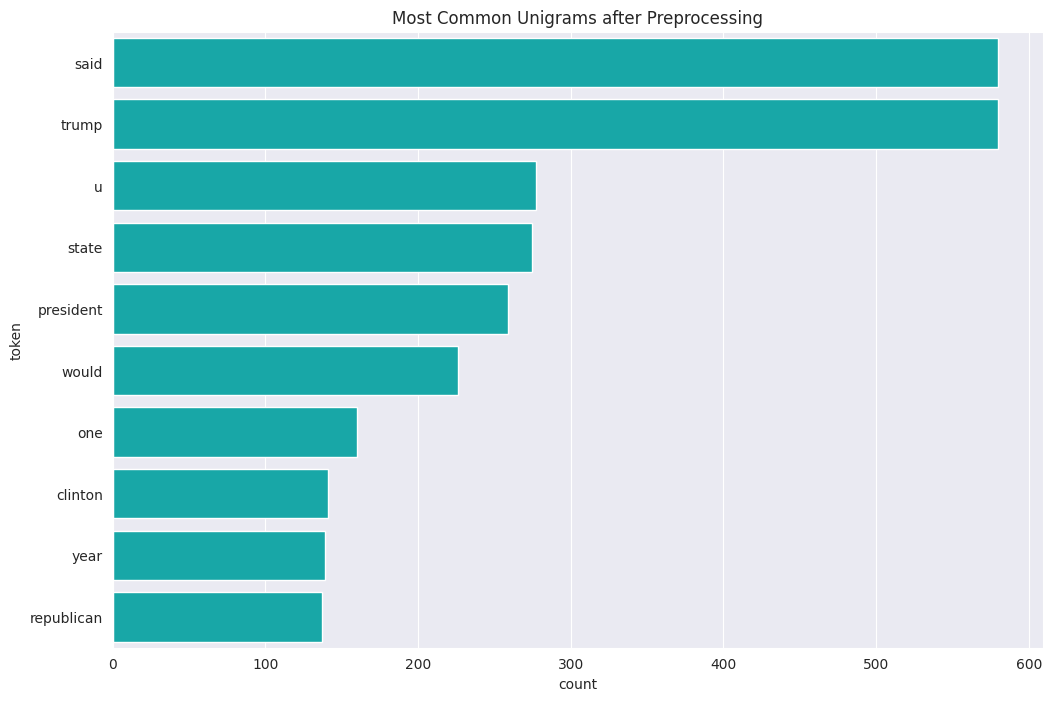

In [189]:
sns.barplot(
    x="count", y="token", data=unigrams, orient="h", palette=[default_plot_color], hue="token", legend=False
).set(title="Most Common Unigrams after Preprocessing")